## Imports + configuration

In [2]:
%pip install tqdm


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import glob
import json
import random
import math
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from tqdm import tqdm

In [4]:
DATASET_DIR = "dataset"

IMAGE_SIZE = 64

BATCH_SIZE = 32
NUM_EPOCHS = 100
LEARNING_RATE = 2e-4

TIMESTEPS = 1000

MAP_CHANNELS = 3
LATENT_CHANNELS = 16
BASE_CHANNELS = 64

TRAIN_RATIO = 0.9

NUM_WORKERS = 4
PREFETCH_FACTOR = 4
PERSISTENT_WORKERS = True

SEED = 42
EVAL_SEED = 2026

PATH_WEIGHT = 5.0

CHECKPOINT_DIR = (
    "checkpoints_cnn_capacity matched_"
    "x0_path_weighted"
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

print("Device:", DEVICE)
print("Conditioning input: obstacle/start/goal only")
print("Map channels:", MAP_CHANNELS)

Device: cuda
Conditioning input: obstacle/start/goal only
Map channels: 3


## Dataset loader

In [5]:
class MazePathDataset(Dataset):

    def __init__(self, dataset_dir):
        self.files = sorted(
            glob.glob(
                os.path.join(
                    dataset_dir,
                    "pair_*.npz",
                )
            )
        )

        if len(self.files) == 0:
            raise RuntimeError(
                f"No .npz files found in {dataset_dir}"
            )

        print(f"Found {len(self.files)} samples.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filepath = self.files[idx]

        with np.load(filepath) as data:
            grid_map = np.asarray(
                data["map"],
                dtype=np.float32,
            )

            path = np.asarray(
                data["path"],
                dtype=np.float32,
            )

        expected_map_shape = (
            MAP_CHANNELS,
            IMAGE_SIZE,
            IMAGE_SIZE,
        )

        if grid_map.shape != expected_map_shape:
            raise ValueError(
                f"{filepath}: expected map shape "
                f"{expected_map_shape}, "
                f"got {grid_map.shape}"
            )

        grid_map = torch.from_numpy(grid_map)
        path = torch.from_numpy(path)

        path = path * 2.0 - 1.0

        return {
            "map": grid_map,
            "path": path,
            "sample_index": int(idx),
        }

## Train / validation split

In [6]:
dataset = MazePathDataset(
    dataset_dir=DATASET_DIR
)

train_size = int(
    len(dataset) * TRAIN_RATIO
)

val_size = len(dataset) - train_size

split_generator = torch.Generator().manual_seed(
    SEED
)

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=split_generator
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

sample0 = dataset[0]

print("Map shape:", sample0["map"].shape)
print("Path shape:", sample0["path"].shape)

assert sample0["map"].shape == (
    MAP_CHANNELS,
    IMAGE_SIZE,
    IMAGE_SIZE,
)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

if NUM_WORKERS > 0:
    loader_kwargs.update(
        persistent_workers=PERSISTENT_WORKERS,
        prefetch_factor=PREFETCH_FACTOR,
    )

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs,
)

Found 10000 samples.
Train: 9000
Validation: 1000
Map shape: torch.Size([3, 64, 64])
Path shape: torch.Size([1, 64, 64])


## CNN Encoder

In [7]:
class CapacityMatchedRawMapEncoder(nn.Module):

    def __init__(
        self,
        in_channels=MAP_CHANNELS,
        latent_channels=LATENT_CHANNELS,
    ):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(
                in_channels,
                32,
                kernel_size=3,
                padding=1,
            ),
            nn.GroupNorm(8, 32),
            nn.SiLU(),

            nn.Conv2d(
                32,
                48,
                kernel_size=3,
                padding=1,
            ),
            nn.GroupNorm(8, 48),
            nn.SiLU(),

            nn.Conv2d(
                48,
                52,
                kernel_size=3,
                padding=1,
            ),
            nn.GroupNorm(4, 52),
            nn.SiLU(),

            nn.Conv2d(
                52,
                32,
                kernel_size=3,
                padding=1,
            ),
            nn.GroupNorm(8, 32),
            nn.SiLU(),

            nn.Conv2d(
                32,
                latent_channels,
                kernel_size=3,
                padding=1,
            ),
        )

    def forward(self, grid_map):
        if grid_map.shape[1] != MAP_CHANNELS:
            raise ValueError(
                f"Expected {MAP_CHANNELS} channels, "
                f"got {grid_map.shape[1]}"
            )

        return self.encoder(grid_map)


encoder_check = CapacityMatchedRawMapEncoder()

encoder_params = sum(
    p.numel()
    for p in encoder_check.parameters()
    if p.requires_grad
)

print(
    "Raw CNN encoder parameters:",
    f"{encoder_params:,}"
)

Raw CNN encoder parameters: 57,244


## Diffusion timestep embedding

In [8]:
class SinusoidalTimeEmbedding(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.dim = dim

    def forward(self, time):

        device = time.device

        half_dim = self.dim // 2

        embeddings = math.log(
            10000
        ) / (half_dim - 1)

        embeddings = torch.exp(
            torch.arange(
                half_dim,
                device=device
            )
            * -embeddings
        )

        embeddings = (
            time[:, None].float()
            *
            embeddings[None, :]
        )

        embeddings = torch.cat(
            (
                embeddings.sin(),
                embeddings.cos()
            ),
            dim=1
        )

        return embeddings

## UNet Residual Block

In [9]:
class ResBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        time_dim
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm1 = nn.GroupNorm(
            8,
            out_channels
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm2 = nn.GroupNorm(
            8,
            out_channels
        )

        self.time_mlp = nn.Linear(
            time_dim,
            out_channels
        )

        if in_channels != out_channels:

            self.residual = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            )

        else:

            self.residual = nn.Identity()

    def forward(
        self,
        x,
        time_emb
    ):

        residual = self.residual(x)

        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)

        # --------------------------------
        # timestep information
        # --------------------------------

        time_feature = self.time_mlp(
            time_emb
        )

        time_feature = time_feature[
            :,
            :,
            None,
            None
        ]

        h = h + time_feature

        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)

        return h + residual

## Conditional UNet

In [10]:
class ConditionalUNet(nn.Module):

    def __init__(
        self,
        map_latent_channels=16,
        base_channels=64,
        time_dim=256
    ):

        super().__init__()

        input_channels = (
            1 + map_latent_channels
        )

        # ========================================
        # Time embedding
        # ========================================

        self.time_embedding = nn.Sequential(

            SinusoidalTimeEmbedding(
                time_dim
            ),

            nn.Linear(
                time_dim,
                time_dim
            ),

            nn.SiLU(),

            nn.Linear(
                time_dim,
                time_dim
            )
        )

        # ========================================
        # Input
        # ========================================

        self.input_conv = nn.Conv2d(
            input_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        # ========================================
        # Encoder
        # ========================================

        self.down1 = ResBlock(
            base_channels,
            base_channels,
            time_dim
        )

        self.pool1 = nn.Conv2d(
            base_channels,
            base_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.down2 = ResBlock(
            base_channels,
            base_channels * 2,
            time_dim
        )

        self.pool2 = nn.Conv2d(
            base_channels * 2,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        # ========================================
        # Bottleneck
        # ========================================

        self.mid1 = ResBlock(
            base_channels * 2,
            base_channels * 4,
            time_dim
        )

        self.mid2 = ResBlock(
            base_channels * 4,
            base_channels * 4,
            time_dim
        )

        # ========================================
        # Decoder
        # ========================================

        self.up2 = nn.ConvTranspose2d(
            base_channels * 4,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.up_block2 = ResBlock(
            base_channels * 4,
            base_channels * 2,
            time_dim
        )

        self.up1 = nn.ConvTranspose2d(
            base_channels * 2,
            base_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.up_block1 = ResBlock(
            base_channels * 2,
            base_channels,
            time_dim
        )

        # ========================================
        # Output
        # ========================================

        self.output = nn.Conv2d(
            base_channels,
            1,
            kernel_size=1
        )

    def forward(
        self,
        x,
        timestep
    ):

        # timestep embedding
        t = self.time_embedding(
            timestep
        )

        # input
        x = self.input_conv(x)

        # ----------------------------------------
        # Down
        # ----------------------------------------

        skip1 = self.down1(
            x,
            t
        )

        x = self.pool1(
            skip1
        )

        skip2 = self.down2(
            x,
            t
        )

        x = self.pool2(
            skip2
        )

        # ----------------------------------------
        # Middle
        # ----------------------------------------

        x = self.mid1(
            x,
            t
        )

        x = self.mid2(
            x,
            t
        )

        # ----------------------------------------
        # Up
        # ----------------------------------------

        x = self.up2(x)

        x = torch.cat(
            [x, skip2],
            dim=1
        )

        x = self.up_block2(
            x,
            t
        )

        x = self.up1(x)

        x = torch.cat(
            [x, skip1],
            dim=1
        )

        x = self.up_block1(
            x,
            t
        )

        return self.output(x)

## DDPM noise schedule

In [11]:
class GaussianDiffusion:

    def __init__(
        self,
        timesteps=1000,
        beta_start=1e-4,
        beta_end=0.02,
        device="cuda"
    ):

        self.timesteps = timesteps
        self.device = device

        # ----------------------------------------
        # Linear beta schedule
        # ----------------------------------------

        self.betas = torch.linspace(
            beta_start,
            beta_end,
            timesteps,
            device=device
        )

        self.alphas = (
            1.0 - self.betas
        )

        self.alpha_cumprod = torch.cumprod(
            self.alphas,
            dim=0
        )

        self.alpha_cumprod_prev = F.pad(
            self.alpha_cumprod[:-1],
            (1, 0),
            value=1.0
        )

        self.sqrt_alpha_cumprod = (
            torch.sqrt(
                self.alpha_cumprod
            )
        )

        self.sqrt_one_minus_alpha_cumprod = (
            torch.sqrt(
                1.0
                -
                self.alpha_cumprod
            )
        )

        self.sqrt_recip_alphas = (
            torch.sqrt(
                1.0 / self.alphas
            )
        )

        # ----------------------------------------
        # Posterior variance
        # ----------------------------------------

        self.posterior_variance = (
            self.betas
            *
            (
                1.0
                -
                self.alpha_cumprod_prev
            )
            /
            (
                1.0
                -
                self.alpha_cumprod
            )
        )

## Helper

In [12]:
def extract(
    values,
    timestep,
    x_shape
):

    batch_size = timestep.shape[0]

    out = values.gather(
        0,
        timestep
    )

    return out.reshape(
        batch_size,
        *((1,) * (len(x_shape) - 1))
    )

## Forward diffusion

In [13]:
def q_sample(
    diffusion,
    x_start,
    timestep,
    noise=None
):

    if noise is None:
        noise = torch.randn_like(
            x_start
        )

    sqrt_alpha_cumprod_t = extract(
        diffusion.sqrt_alpha_cumprod,
        timestep,
        x_start.shape
    )

    sqrt_one_minus_alpha_cumprod_t = (
        extract(
            diffusion.sqrt_one_minus_alpha_cumprod,
            timestep,
            x_start.shape
        )
    )

    noisy_path = (
        sqrt_alpha_cumprod_t
        *
        x_start

        +

        sqrt_one_minus_alpha_cumprod_t
        *
        noise
    )

    return noisy_path, noise

## Training function

In [14]:
class DiffusionPathPlanner(nn.Module):

    def __init__(
        self,
        latent_channels=LATENT_CHANNELS,
        base_channels=BASE_CHANNELS,
    ):
        super().__init__()

        self.map_encoder = CapacityMatchedRawMapEncoder(
            in_channels=MAP_CHANNELS,
            latent_channels=latent_channels,
        )

        self.unet = ConditionalUNet(
            map_latent_channels=latent_channels,
            base_channels=base_channels,
        )

    def encode_map(self, grid_map):
        return self.map_encoder(grid_map)

    def predict_x0(
        self,
        noisy_path,
        map_latent,
        timestep,
    ):
        model_input = torch.cat(
            [
                noisy_path,
                map_latent,
            ],
            dim=1,
        )

        return self.unet(
            model_input,
            timestep,
        )

    def forward(
        self,
        grid_map,
        noisy_path,
        timestep,
    ):
        map_latent = self.encode_map(
            grid_map
        )

        return self.predict_x0(
            noisy_path,
            map_latent,
            timestep,
        )

In [15]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    diffusion,
    device
):

    model.train()

    total_loss = 0.0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for batch in progress_bar:

        grid_map = batch["map"].to(
            device,
            non_blocking=True
        )

        path = batch["path"].to(
            device,
            non_blocking=True
        )

        batch_size = path.shape[0]

        # ----------------------------------------
        # Random timestep
        # ----------------------------------------

        timestep = torch.randint(
            0,
            diffusion.timesteps,
            (batch_size,),
            device=device
        ).long()

        # ----------------------------------------
        # Forward diffusion
        #
        # path = clean x0
        # noisy_path = x_t
        # ----------------------------------------

        noisy_path, _ = q_sample(
            diffusion,
            path,
            timestep
        )

        # ----------------------------------------
        # Predict clean x0
        # ----------------------------------------

        predicted_x0 = model(
            grid_map,
            noisy_path,
            timestep
        )

        # ============================================================
        # Weighted x0 reconstruction loss
        # ============================================================

        path_mask = (
            path > 0
        ).float()

        weights = (
            1.0
            +
            (PATH_WEIGHT - 1.0)
            *
            path_mask
        )

        squared_error = (
            predicted_x0
            -
            path
        ).pow(2)

        loss = (
            weights
            *
            squared_error
        ).mean()

        optimizer.zero_grad(
            set_to_none=True
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return (
        total_loss
        /
        len(loader)
    )

## Validation function

In [16]:
@torch.no_grad()
def validate(
    model,
    loader,
    diffusion,
    device
):

    model.eval()

    total_loss = 0.0

    for batch in loader:

        grid_map = batch["map"].to(
            device,
            non_blocking=True
        )

        path = batch["path"].to(
            device,
            non_blocking=True
        )

        batch_size = path.shape[0]

        timestep = torch.randint(
            0,
            diffusion.timesteps,
            (batch_size,),
            device=device
        ).long()

        # ----------------------------------------
        # Forward diffusion
        # ----------------------------------------

        noisy_path, _ = q_sample(
            diffusion,
            path,
            timestep
        )

        predicted_x0 = model(
            grid_map,
            noisy_path,
            timestep
        )

        path_mask = (
            path > 0
        ).float()

        weights = (
            1.0
            +
            (PATH_WEIGHT - 1.0)
            *
            path_mask
        )

        squared_error = (
            predicted_x0
            -
            path
        ).pow(2)

        loss = (
            weights
            *
            squared_error
        ).mean()

        total_loss += loss.item()

    return (
        total_loss
        /
        len(loader)
    )

In [17]:
os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True,
)

model = DiffusionPathPlanner(
    latent_channels=LATENT_CHANNELS,
    base_channels=BASE_CHANNELS,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
)

diffusion = GaussianDiffusion(
    timesteps=TIMESTEPS,
    device=DEVICE,
)

total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Total trainable parameters:",
    f"{total_params:,}"
)

Total trainable parameters: 4,412,573


## Full training loop

In [18]:
best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(
    1,
    NUM_EPOCHS + 1,
):

    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        diffusion,
        DEVICE,
    )

    val_loss = validate(
        model,
        val_loader,
        diffusion,
        DEVICE,
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train loss: {train_loss:.6f}")
    print(f"Val loss:   {val_loss:.6f}")

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
        },
        os.path.join(
            CHECKPOINT_DIR,
            "latest.pt",
        ),
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
            },
            os.path.join(
                CHECKPOINT_DIR,
                "best.pt",
            ),
        )

        print(
            f"Saved new best model: "
            f"{best_val_loss:.6f}"
        )


Epoch 1/100


Train loss: 0.207381
Val loss:   0.160851
Saved new best model: 0.160851

Epoch 2/100


Train loss: 0.149029
Val loss:   0.140185
Saved new best model: 0.140185

Epoch 3/100


Train loss: 0.131705
Val loss:   0.135788
Saved new best model: 0.135788

Epoch 4/100


Train loss: 0.118921
Val loss:   0.120538
Saved new best model: 0.120538

Epoch 5/100


...

Train loss: 0.003406
Val loss:   0.078861

Epoch 97/100


Train loss: 0.005176
Val loss:   0.065186

Epoch 98/100


Train loss: 0.005738
Val loss:   0.077395

Epoch 99/100


Train loss: 0.003581
Val loss:   0.084914

Epoch 100/100


Train loss: 0.002788
Val loss:   0.085711


## Plot loss curve

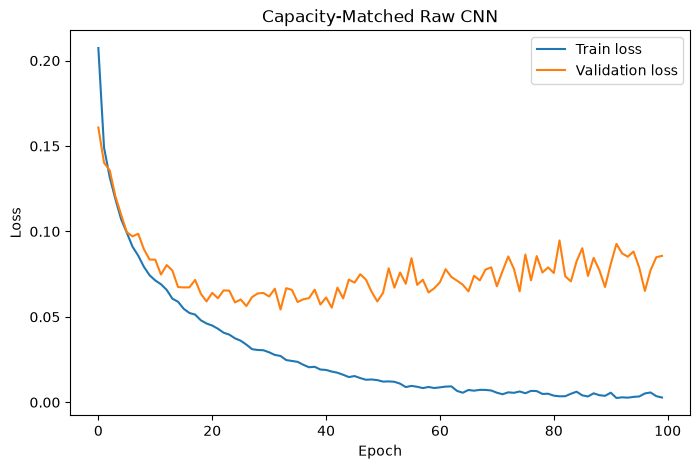

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Capacity-Matched Raw CNN")
plt.legend()
plt.show()

In [20]:
best_checkpoint = torch.load(
    os.path.join(
        CHECKPOINT_DIR,
        "best.pt",
    ),
    map_location=DEVICE,
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

model.eval()

print(
    "Loaded best epoch:",
    best_checkpoint["epoch"]
)

print(
    "Best validation loss:",
    best_checkpoint["val_loss"]
)

Loaded best epoch: 33
Best validation loss: 0.05431018432136625


/tmp/ipykernel_5098/1778156898.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_checkpoint = torch.load(


## Reverse diffusion / inference

In [21]:
@torch.no_grad()
def p_sample(
    model,
    diffusion,
    x,
    map_latent,
    timestep,
    timestep_index
):

    # ========================================
    # Predict clean x0
    # ========================================

    predicted_x0 = model.predict_x0(
        x,
        map_latent,
        timestep
    )

    # Keep prediction in training data range
    predicted_x0 = torch.clamp(
        predicted_x0,
        -1.0,
        1.0
    )

    # ========================================
    # Extract diffusion coefficients
    # ========================================

    beta_t = extract(
        diffusion.betas,
        timestep,
        x.shape
    )

    alpha_t = extract(
        diffusion.alphas,
        timestep,
        x.shape
    )

    alpha_cumprod_t = extract(
        diffusion.alpha_cumprod,
        timestep,
        x.shape
    )

    alpha_cumprod_prev_t = extract(
        diffusion.alpha_cumprod_prev,
        timestep,
        x.shape
    )

    # ========================================
    # Posterior mean:
    #
    # q(x_{t-1} | x_t, x0)
    # ========================================

    coefficient_x0 = (
        torch.sqrt(
            alpha_cumprod_prev_t
        )
        *
        beta_t
        /
        (
            1.0
            -
            alpha_cumprod_t
        )
    )

    coefficient_xt = (
        torch.sqrt(
            alpha_t
        )
        *
        (
            1.0
            -
            alpha_cumprod_prev_t
        )
        /
        (
            1.0
            -
            alpha_cumprod_t
        )
    )

    model_mean = (
        coefficient_x0
        *
        predicted_x0
        +
        coefficient_xt
        *
        x
    )

    # ========================================
    # Final step: no additional noise
    # ========================================

    if timestep_index == 0:
        return model_mean

    # ========================================
    # Posterior variance
    # ========================================

    posterior_variance_t = extract(
        diffusion.posterior_variance,
        timestep,
        x.shape
    )

    noise = torch.randn_like(
        x
    )

    return (
        model_mean
        +
        torch.sqrt(
            posterior_variance_t
        )
        *
        noise
    )

In [22]:
@torch.no_grad()
def sample_path(
    model,
    diffusion,
    grid_map,
    device,
    show_progress=False,
):
    """
    Generate one path sample.

    IMPORTANT:
    During large validation runs, keep show_progress=False.
    This prevents 1000 nested tqdm progress bars from flooding
    Jupyter's output channel.
    """

    model.eval()

    grid_map = grid_map.to(
        device,
        non_blocking=True,
    )

    if grid_map.dim() == 3:
        grid_map = grid_map.unsqueeze(0)

    batch_size = grid_map.shape[0]

    # ========================================
    # Encode map ONCE
    # ========================================

    map_latent = model.encode_map(
        grid_map
    )

    # ========================================
    # Start from pure Gaussian noise
    # ========================================

    x = torch.randn(
        batch_size,
        1,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=device
    )

    # ========================================
    # Reverse diffusion
    # ========================================

    timestep_iterator = reversed(
        range(
            diffusion.timesteps
        )
    )

    if show_progress:
        timestep_iterator = tqdm(
            timestep_iterator,
            total=diffusion.timesteps,
            desc="Sampling",
            leave=False,
        )

    for i in timestep_iterator:

        timestep = torch.full(
            (batch_size,),
            i,
            device=device,
            dtype=torch.long
        )

        x = p_sample(
            model,
            diffusion,
            x,
            map_latent,
            timestep,
            i
        )

    # ========================================
    # [-1,1] -> [0,1]
    # ========================================

    x = (
        x + 1.0
    ) / 2.0

    x = torch.clamp(
        x,
        0.0,
        1.0
    )

    return x

## Validation evaluator

In [23]:
def check_4neighbor_connection(
    binary_path,
    start,
    goal
):
    """
    binary_path: numpy array [H, W], bool
    start: (y, x)
    goal: (y, x)

    Returns:
        True if goal is reachable from start
        using only 4-neighbor path pixels.
    """

    H, W = binary_path.shape

    sy, sx = start
    gy, gx = goal

    # start / goal must both belong to path
    if not binary_path[sy, sx]:
        return False

    if not binary_path[gy, gx]:
        return False

    visited = np.zeros(
        (H, W),
        dtype=bool
    )

    queue = deque()

    queue.append(
        (sy, sx)
    )

    visited[sy, sx] = True

    directions = [
        (-1, 0),   # up
        (1, 0),    # down
        (0, -1),   # left
        (0, 1)     # right
    ]

    while queue:

        y, x = queue.popleft()

        # reached goal
        if (y, x) == (gy, gx):
            return True

        for dy, dx in directions:

            ny = y + dy
            nx = x + dx

            if (
                0 <= ny < H
                and
                0 <= nx < W
            ):

                if (
                    binary_path[ny, nx]
                    and
                    not visited[ny, nx]
                ):

                    visited[ny, nx] = True

                    queue.append(
                        (ny, nx)
                    )

    return False

In [24]:
@torch.no_grad()
def evaluate_single_sample(
    model,
    diffusion,
    sample,
    device,
    threshold=0.5
):
    """
    Evaluate one generated path.
    """

    grid_map = sample["map"]

    # ========================================
    # Generate predicted path
    # Inner diffusion progress is DISABLED.
    # ========================================

    predicted_path = sample_path(
        model,
        diffusion,
        grid_map,
        device,
        show_progress=False,
    )

    pred = (
        predicted_path[0, 0]
        .detach()
        .cpu()
        .numpy()
    )

    binary_path = (
        pred > threshold
    )

    # ========================================
    # Extract raw-map channels
    # ========================================

    obstacle = (
        grid_map[0]
        .cpu()
        .numpy()
        > 0.5
    )

    start_map = (
        grid_map[1]
        .cpu()
        .numpy()
        > 0.5
    )

    goal_map = (
        grid_map[2]
        .cpu()
        .numpy()
        > 0.5
    )

    start_y, start_x = np.where(
        start_map
    )

    goal_y, goal_x = np.where(
        goal_map
    )

    if len(start_y) != 1:
        raise ValueError(
            "Expected exactly one start cell."
        )

    if len(goal_y) != 1:
        raise ValueError(
            "Expected exactly one goal cell."
        )

    start = (
        int(start_y[0]),
        int(start_x[0])
    )

    goal = (
        int(goal_y[0]),
        int(goal_x[0])
    )

    sy, sx = start
    gy, gx = goal

    start_in_path = bool(
        binary_path[sy, sx]
    )

    goal_in_path = bool(
        binary_path[gy, gx]
    )

    collision_mask = (
        binary_path
        &
        obstacle
    )

    collision_count = int(
        collision_mask.sum()
    )

    collision_free = (
        collision_count == 0
    )

    connected = (
        check_4neighbor_connection(
            binary_path,
            start,
            goal
        )
    )

    return {
        "start_in_path": start_in_path,
        "goal_in_path": goal_in_path,
        "collision_free": collision_free,
        "collision_count": collision_count,
        "connected": connected,
    }

In [25]:
def summarize_results(
    results
):

    total = len(
        results
    )

    if total == 0:
        print(
            "No results to summarize."
        )
        return

    start_rate = np.mean(
        [
            r["start_in_path"]
            for r in results
        ]
    )

    goal_rate = np.mean(
        [
            r["goal_in_path"]
            for r in results
        ]
    )

    collision_free_rate = np.mean(
        [
            r["collision_free"]
            for r in results
        ]
    )

    connected_rate = np.mean(
        [
            r["connected"]
            for r in results
        ]
    )

    avg_collisions = np.mean(
        [
            r["collision_count"]
            for r in results
        ]
    )

    valid_success = np.mean(
        [
            (
                r["start_in_path"]
                and
                r["goal_in_path"]
                and
                r["collision_free"]
                and
                r["connected"]
            )
            for r in results
        ]
    )

    print(
        f"Samples evaluated: {total}"
    )

    print(
        f"Start included:      "
        f"{start_rate * 100:.2f}%"
    )

    print(
        f"Goal included:       "
        f"{goal_rate * 100:.2f}%"
    )

    print(
        f"Collision-free:      "
        f"{collision_free_rate * 100:.2f}%"
    )

    print(
        f"Connected S -> G:    "
        f"{connected_rate * 100:.2f}%"
    )

    print(
        f"Average collisions:  "
        f"{avg_collisions:.2f}"
    )

    print(
        f"Valid Path Success:  "
        f"{valid_success * 100:.2f}%"
    )

    return float(
        valid_success
    )

In [26]:
@torch.no_grad()
def evaluate_validation_set(
    model,
    diffusion,
    dataset,
    device,
    num_samples=1000,
    threshold=0.5,
    desc="Evaluating",
):
    model.eval()

    num_samples = min(
        num_samples,
        len(dataset)
    )

    results = []

    progress = tqdm(
        range(num_samples),
        desc=desc,
        total=num_samples,
        dynamic_ncols=True,
    )

    for idx in progress:

        sample = dataset[idx]

        result = evaluate_single_sample(
            model=model,
            diffusion=diffusion,
            sample=sample,
            device=device,
            threshold=threshold,
        )

        result["index"] = int(idx)
        result["sample_index"] = int(
            sample["sample_index"]
        )

        results.append(result)

        valid_count = sum(
            (
                r["start_in_path"]
                and
                r["goal_in_path"]
                and
                r["collision_free"]
                and
                r["connected"]
            )
            for r in results
        )

        progress.set_postfix(
            success=(
                f"{100.0 * valid_count / len(results):.1f}%"
            )
        )

    return results

In [27]:
random.seed(EVAL_SEED)
np.random.seed(EVAL_SEED)
torch.manual_seed(EVAL_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(EVAL_SEED)

results = evaluate_validation_set(
    model=model,
    diffusion=diffusion,
    dataset=val_dataset,
    device=DEVICE,
    num_samples=1000,
    threshold=0.5,
    desc="Capacity-matched raw CNN",
)

valid_success = summarize_results(results)

print()
print(
    "Final Valid Path Success:",
    f"{valid_success * 100:.2f}%"
)

Capacity-matched raw CNN: 100%|██████████| 1000/1000 [49:47<00:00,  2.99s/it, success=78.1%]

Samples evaluated: 1000
Start included:      100.00%
Goal included:       100.00%
Collision-free:      96.60%
Connected S -> G:    81.00%
Average collisions:  0.06
Valid Path Success:  78.10%

Final Valid Path Success: 78.10%
